# putEMG — Multi-Model Training & Evaluation

Trains and evaluates 5 architectures on the putEMG gesture dataset using a
single train/val split with early stopping and learning-rate scheduling,
then evaluates each model on the held-out test set.

| # | Model | Description |
|---|-------|-------------|
| 1 | **EEGNet** | Depthwise separable CNN, original baseline |
| 2 | **ShallowConvNet** | Temporal + spatial conv, square/log nonlinearity |
| 3 | **DeepConvNet** | 4 stacked conv blocks, increasing filter depth |
| 4 | **CNN_LSTM** | Spatial CNN → temporal pooling → 2-layer LSTM |
| 5 | **EMG_TCN** | Spatial mixing + 4 dilated temporal conv blocks |

**Data splits:**
- 80% training set (further split 90/10 into train/val for early stopping)
- 20% held-out test set → final evaluation only

In [28]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
## Configuration

Set paths, CV parameters, and hyperparameter grid here.

In [30]:
# ── Data ──────────────────────────────────────────────────────────────────────
FILE_PATH = '/Users/chrisdollo/Documents/Research/putEMG prime/Data/X/model_ready_5/model_ready_5_sub.mat'

# ── Splits ────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2   # held-out test set
VAL_SIZE     = 0.1   # validation split from training set (for early stopping)

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
MAX_EPOCHS   = 50
PATIENCE     = 15       # early-stopping patience (epochs without improvement)
MIN_DELTA    = 0.002    # minimum improvement to reset patience

# ── Hyperparameters (single values — no grid search) ─────────────────────────
DROPOUT      = 0.25
LR           = 1e-3

# ── Dataset constants ─────────────────────────────────────────────────────────
NUM_CLASSES   = 7
NUM_CHANNELS  = 24
INPUT_SAMPLES = 1500

---
## Model Definitions

All models accept `(batch, 1, 24, 1500)` input and output `(batch, 7)` logits.
Each constructor takes `dropout_rate` so the hyperparameter search works uniformly.

In [31]:
# ── 1. EEGNet ─────────────────────────────────────────────────────────────────
class EEGNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_channels=NUM_CHANNELS,
                 input_samples=INPUT_SAMPLES, dropout_rate=0.25,
                 kernel_length=64, F1=8, D=2, F2=16):
        super(EEGNet, self).__init__()

        self.firstConv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernel_length),
                      padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(num_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(p=dropout_rate)
        )
        self.separableConv = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=dropout_rate)
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_channels, input_samples)
            x = self.separableConv(self.depthwiseConv(self.firstConv(dummy)))
            flat = x.shape[1] * x.shape[2] * x.shape[3]
        self.classify = nn.Sequential(nn.Flatten(), nn.Linear(flat, num_classes))

    def forward(self, x):
        x = self.firstConv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        return self.classify(x)

In [32]:
# ── 2. ShallowConvNet (Schirrmeister et al., 2017) ────────────────────────────
#
# Architecture:
#   temporal conv (1×25) → spatial depthwise conv (C×1)
#   → square nonlinearity → average pool → log nonlinearity → FC
#
# Rationale: specifically designed for EEG/EMG, leverages band-power features
# via the square+log pipeline (equivalent to log-power of filtered signal).

class ShallowConvNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_channels=NUM_CHANNELS,
                 input_samples=INPUT_SAMPLES, dropout_rate=0.5, n_filters=40):
        super(ShallowConvNet, self).__init__()

        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, n_filters, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(n_filters)
        )
        # Depthwise spatial conv across all channels
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, kernel_size=(num_channels, 1),
                      groups=n_filters, bias=False),
            nn.BatchNorm2d(n_filters)
        )
        self.pool    = nn.AvgPool2d(kernel_size=(1, 75), stride=(1, 15))
        self.dropout = nn.Dropout(p=dropout_rate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_channels, input_samples)
            x = self.temporal_conv(dummy)
            x = self.spatial_conv(x)
            x = x ** 2
            x = self.pool(x)
            x = torch.log(torch.clamp(x, min=1e-6))
            flat = x.flatten(1).shape[1]

        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(flat, num_classes))

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = x ** 2
        x = self.pool(x)
        x = torch.log(torch.clamp(x, min=1e-6))
        x = self.dropout(x)
        return self.classifier(x)

In [33]:
# ── 3. DeepConvNet (Schirrmeister et al., 2017) ───────────────────────────────
#
# Architecture:
#   Block 1: temporal conv (1×5) → spatial conv (C×1) → BN → ELU → MaxPool
#   Blocks 2–4: Conv(1×5) → BN → ELU → MaxPool, filters: 25→50→100→200
#   → FC
#
# Rationale: deeper hierarchy extracts progressively abstract temporal features.
# Standard deep-learning EEG/EMG baseline.

class DeepConvNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_channels=NUM_CHANNELS,
                 input_samples=INPUT_SAMPLES, dropout_rate=0.5):
        super(DeepConvNet, self).__init__()

        def conv_block(in_f, out_f, kernel, pool, drop):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, kernel, bias=False),
                nn.BatchNorm2d(out_f),
                nn.ELU(),
                nn.MaxPool2d(pool),
                nn.Dropout(p=drop)
            )

        # Block 1: separate temporal and spatial convolutions
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 25, kernel_size=(1, 5), bias=False),
            nn.Conv2d(25, 25, kernel_size=(num_channels, 1), bias=False),
            nn.BatchNorm2d(25),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(p=dropout_rate)
        )
        self.block2 = conv_block(25,  50,  (1, 5), (1, 2), dropout_rate)
        self.block3 = conv_block(50,  100, (1, 5), (1, 2), dropout_rate)
        self.block4 = conv_block(100, 200, (1, 5), (1, 2), dropout_rate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_channels, input_samples)
            x = self.block4(self.block3(self.block2(self.block1(dummy))))
            flat = x.flatten(1).shape[1]

        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(flat, num_classes))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)

In [34]:
# ── 4. CNN_LSTM ────────────────────────────────────────────────────────────────
#
# Architecture:
#   Spatial CNN (C×1 depthwise) → temporal downsampling → 2-layer LSTM → FC
#
# Rationale: the CNN extracts spatial electrode features; the LSTM models
# sequential temporal dynamics across the gesture. Temporal pooling (×15)
# reduces the 1500-step sequence to 100 steps before the LSTM.

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_channels=NUM_CHANNELS,
                 input_samples=INPUT_SAMPLES, dropout_rate=0.25,
                 cnn_filters=32, lstm_hidden=64, lstm_layers=2):
        super(CNN_LSTM, self).__init__()

        # Spatial mixing across electrode channels
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(1, cnn_filters, kernel_size=(num_channels, 1), bias=False),
            nn.BatchNorm2d(cnn_filters),
            nn.ELU(),
            nn.Dropout(p=dropout_rate)
        )
        # Output: (B, cnn_filters, 1, input_samples) → squeeze → (B, cnn_filters, input_samples)

        # Downsample time axis before LSTM  (1500 → 100)
        self.temporal_pool = nn.AvgPool1d(kernel_size=15)

        self.lstm = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout_rate if lstm_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(lstm_hidden, num_classes)
        )

    def forward(self, x):
        x = self.spatial_conv(x)       # (B, 32, 1, 1500)
        x = x.squeeze(2)               # (B, 32, 1500)
        x = self.temporal_pool(x)      # (B, 32, 100)
        x = x.permute(0, 2, 1)        # (B, 100, 32)
        x, _ = self.lstm(x)            # (B, 100, 64)
        x = x[:, -1, :]               # (B, 64)  — last time step
        return self.classifier(x)

In [35]:
# ── 5. EMG_TCN (Temporal Convolutional Network) ───────────────────────────────
#
# Architecture:
#   Spatial mixing (C×1 conv) → 4 dilated TCN residual blocks → global avg pool → FC
#   Dilations: 1, 2, 4, 8  |  Filters: 32→64→64→128
#
# Rationale: dilated convolutions expand the receptive field exponentially
# without increasing parameters, capturing both fine and coarse temporal
# structure. Well-suited for long EMG sequences. No vanishing gradient issues.

class _TCNBlock(nn.Module):
    """Single residual dilated causal conv block."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        # Causal padding: pad only the left side
        pad = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.ELU(),
            nn.Dropout(p=dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.ELU(),
            nn.Dropout(p=dropout)
        )
        self.pad    = pad
        self.resize = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.net(x)
        out = out[:, :, :x.size(2)]    # trim causal padding
        res = x if self.resize is None else self.resize(x)
        return F.elu(out + res)


class EMG_TCN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_channels=NUM_CHANNELS,
                 input_samples=INPUT_SAMPLES, dropout_rate=0.25):
        super(EMG_TCN, self).__init__()

        # Spatial mixing across electrode channels
        self.spatial = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(num_channels, 1), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        # Output: (B, 32, 1, 1500) → squeeze → (B, 32, 1500)

        # Stacked dilated TCN blocks
        specs = [(32, 64, 1), (64, 64, 2), (64, 128, 4), (128, 128, 8)]
        self.tcn = nn.Sequential(*[
            _TCNBlock(in_ch, out_ch, kernel_size=3, dilation=dil, dropout=dropout_rate)
            for in_ch, out_ch, dil in specs
        ])

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.spatial(x)    # (B, 32, 1, 1500)
        x = x.squeeze(2)       # (B, 32, 1500)
        x = self.tcn(x)        # (B, 128, 1500)
        return self.classifier(x)

---
## Training & Evaluation Functions

Preserved exactly from `model_latest.ipynb`.

In [36]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total


def evaluateFinal(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    actual    = torch.tensor([])
    predicted = torch.tensor([])
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct   += (pred == y).sum().item()
            total     += y.size(0)
            actual    = torch.cat((actual,    y.cpu()),   dim=0)
            predicted = torch.cat((predicted, pred.cpu()), dim=0)

        print(np.unique(predicted.numpy(), return_counts=True))
        cm = confusion_matrix(actual.numpy(), predicted.numpy())
        ConfusionMatrixDisplay(cm).plot()

    print(f"The accuracy for the test is {(correct / total) * 100:.2f}%")
    return correct / total

In [37]:
class BCIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

---
## Load & Prepare Data

Same loading and reshaping as `model_latest.ipynb`.

In [38]:
def load_data_method_1(file_path):
    """
    Original method - iterates gesture_type then row.
    """
    mat_file   = scipy.io.loadmat(file_path)
    cell_array = mat_file["combinedCell"]

    X, Y = [], []
    num_classes       = cell_array.shape[1]
    num_training_ex   = cell_array.shape[0]

    print("num_classes",     num_classes)
    print("num_training_ex", num_training_ex)

    for gesture_type in range(num_classes):
        for row_idx in range(num_training_ex):
            cell = cell_array[row_idx, gesture_type]
            cell = np.array(cell)
            X.append(cell.astype(np.float32))
            Y.append(gesture_type)

    return np.array(X), np.array(Y)

In [39]:
X, Y = load_data_method_1(FILE_PATH)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Unique labels: {np.unique(Y, return_counts=True)}")

# Reshape to (N, 1, channels, samples) — model input format
X = X[:, np.newaxis, :, :]
X = np.transpose(X, (0, 1, 3, 2))
Y = Y.squeeze().astype(np.int64)

print(f"\nAfter reshape — X: {X.shape}, Y: {Y.shape}")

# 80/20 train/test split — test set held out until final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=TEST_SIZE, stratify=Y, random_state=RANDOM_STATE
)

# 90/10 train/val split from training set — used only for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=RANDOM_STATE
)

train_ds = BCIDataset(X_tr,   y_tr)
val_ds   = BCIDataset(X_val,  y_val)
test_ds  = BCIDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

num_classes 7
num_training_ex 200
X shape: (1400, 1500, 24)
Y shape: (1400,)
Unique labels: (array([0, 1, 2, 3, 4, 5, 6]), array([200, 200, 200, 200, 200, 200, 200]))

After reshape — X: (1400, 1, 24, 1500), Y: (1400,)
Train: 1008 | Val: 112 | Test: 280


---
## Training

Each model is trained on the training set with:
- **Early stopping** — stops when val accuracy doesn't improve by `MIN_DELTA` for `PATIENCE` epochs
- **ReduceLROnPlateau** — halves the LR when val accuracy plateaus for 5 epochs
- **Best-state checkpointing** — restores the best-val-acc weights before test evaluation


  Training: EEGNet
  Epoch   1: loss=1.7628  val=42.86%  best=42.86%  lr=1.00e-03
  Epoch   2: loss=1.3052  val=55.36%  best=55.36%  lr=1.00e-03
  Epoch   3: loss=1.0392  val=58.93%  best=58.93%  lr=1.00e-03
  Epoch   4: loss=0.8901  val=62.50%  best=62.50%  lr=1.00e-03
  Epoch   5: loss=0.7771  val=71.43%  best=71.43%  lr=1.00e-03
  Epoch   6: loss=0.6988  val=68.75%  best=71.43%  lr=1.00e-03
  Epoch   7: loss=0.6221  val=73.21%  best=73.21%  lr=1.00e-03
  Epoch   8: loss=0.6046  val=72.32%  best=73.21%  lr=1.00e-03
  Epoch   9: loss=0.5498  val=78.57%  best=78.57%  lr=1.00e-03
  Epoch  10: loss=0.5033  val=81.25%  best=81.25%  lr=1.00e-03
  Epoch  11: loss=0.4764  val=73.21%  best=81.25%  lr=1.00e-03
  Epoch  12: loss=0.4326  val=75.89%  best=81.25%  lr=1.00e-03
  Epoch  13: loss=0.4296  val=80.36%  best=81.25%  lr=1.00e-03
  Epoch  14: loss=0.3987  val=83.04%  best=83.04%  lr=1.00e-03
  Epoch  15: loss=0.3969  val=81.25%  best=83.04%  lr=1.00e-03
  Epoch  16: loss=0.3771  val=77.68

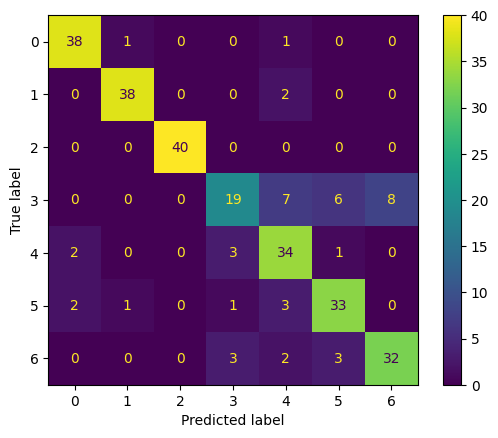

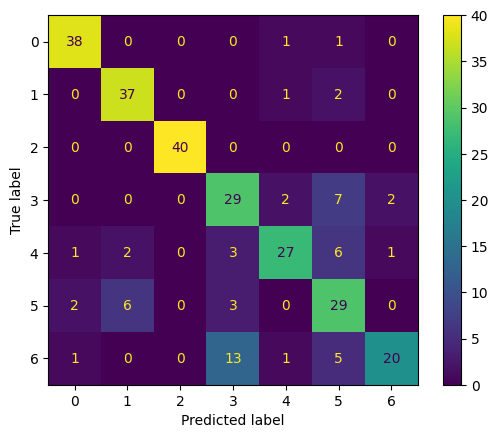

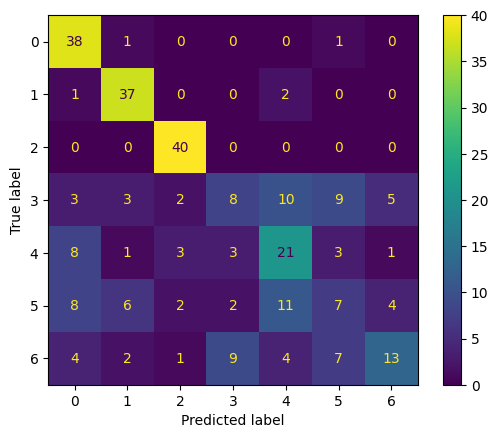

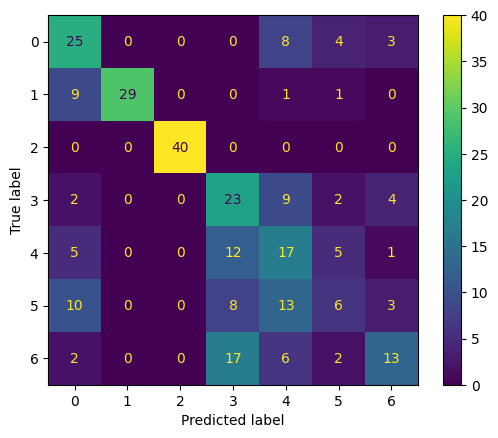

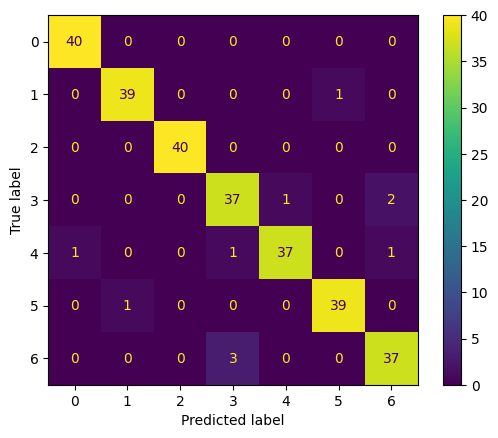

In [40]:
model_registry = {
    'EEGNet':         lambda: EEGNet(dropout_rate=DROPOUT),
    'ShallowConvNet': lambda: ShallowConvNet(dropout_rate=DROPOUT),
    'DeepConvNet':    lambda: DeepConvNet(dropout_rate=DROPOUT),
    'CNN_LSTM':       lambda: CNN_LSTM(dropout_rate=DROPOUT),
    'EMG_TCN':        lambda: EMG_TCN(dropout_rate=DROPOUT),
}

test_accs = {}

for name, build_fn in model_registry.items():
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")

    model     = build_fn().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                  patience=5, min_lr=1e-6)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = float('-inf')
    best_state   = None
    bad_epochs   = 0

    for epoch in range(MAX_EPOCHS):
        tr_loss  = train(model, train_loader, criterion, optimizer, device)
        val_acc  = evaluate(model, val_loader, device)
        curr_lr  = optimizer.param_groups[0]['lr']

        # Best-state checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # Learning-rate scheduler (monitors val accuracy)
        scheduler.step(val_acc)

        # Early stopping
        if val_acc >= (best_val_acc - MIN_DELTA):
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f"  Epoch {epoch+1:3d}: loss={tr_loss:.4f}  val={val_acc*100:.2f}%  "
              f"best={best_val_acc*100:.2f}%  lr={curr_lr:.2e}")

        if bad_epochs >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}.")
            break

    # Restore best weights
    model.load_state_dict(best_state)

    print(f"\n--- {name} — Test Set Evaluation ---")
    test_acc = evaluateFinal(model, test_loader, device)
    test_accs[name] = test_acc

---
## Results Summary


Model                Test Acc
------------------------------
EEGNet                 83.57%
ShallowConvNet         78.57%
DeepConvNet            58.57%
CNN_LSTM               54.64%
EMG_TCN                96.07%


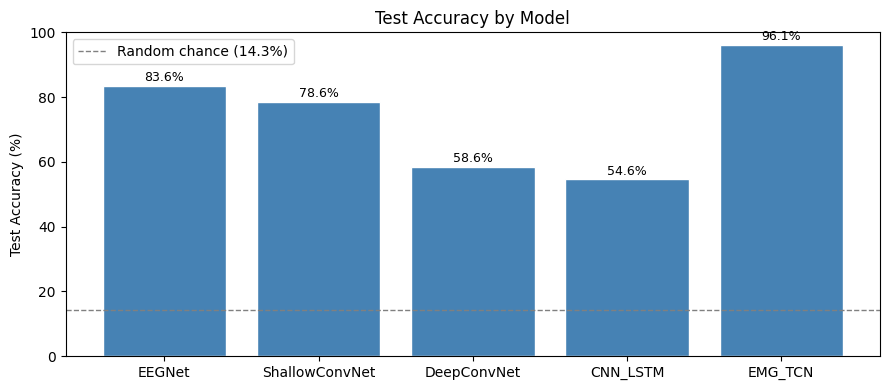

In [41]:
print(f"\n{'Model':<18} {'Test Acc':>10}")
print("-" * 30)
for name in model_registry:
    acc = test_accs.get(name, float('nan')) * 100
    print(f"{name:<18} {acc:>9.2f}%")

names = list(model_registry.keys())
accs  = [test_accs.get(n, 0) * 100 for n in names]

plt.figure(figsize=(9, 4))
bars = plt.bar(names, accs, color='steelblue', edgecolor='white')
plt.axhline(y=14.3, color='gray', linestyle='--', linewidth=1, label='Random chance (14.3%)')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy by Model')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
print(f"\n{'='*60}")
print(f"  Training: {name}")
print(f"{'='*60}")

model     = EMG_TCN(dropout_rate=DROPOUT).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                  patience=5, min_lr=1e-6)
criterion = nn.CrossEntropyLoss()

best_val_acc = float('-inf')
best_state   = None
bad_epochs   = 0

for epoch in range(MAX_EPOCHS):
    tr_loss  = train(model, train_loader, criterion, optimizer, device)
    val_acc  = evaluate(model, val_loader, device)
    curr_lr  = optimizer.param_groups[0]['lr']

    # Best-state checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # Learning-rate scheduler (monitors val accuracy)
        scheduler.step(val_acc)

        # Early stopping
        if val_acc >= (best_val_acc - MIN_DELTA):
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f"  Epoch {epoch+1:3d}: loss={tr_loss:.4f}  val={val_acc*100:.2f}%  "
              f"best={best_val_acc*100:.2f}%  lr={curr_lr:.2e}")

        if bad_epochs >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}.")
            break

# Restore best weights
model.load_state_dict(best_state)

print(f"\n--- {name} — Test Set Evaluation ---")
test_acc = evaluateFinal(model, test_loader, device)
test_accs[name] = test_acc


  Training: EMG_TCN
  Epoch   1: loss=1.3433  val=42.86%  best=42.86%  lr=1.00e-03


KeyboardInterrupt: 